# Cloning Quasars 

Numerical simulations of the measurment process are often the only practical way to assess the complicated influences of selection effects, biases, and other processing stages of data taking.

In [98]:
from astroML.datasets import fetch_dr7_quasar

data = fetch_dr7_quasar()

data = data[:10000]

z = data['redshift']

In [99]:
import numpy as np
import matplotlib.pyplot as plt

Text(0, 0.5, 'Counts of Quasars')

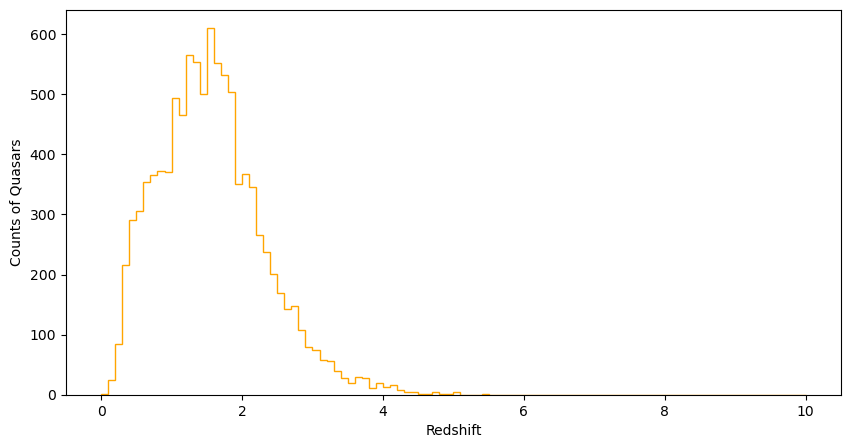

In [ ]:
counts, edges =np.histogram(z,bins=np.linspace(0,10,101))

plt.figure(figsize=(10,5))
plt.hist(z, bins=edges, histtype='step', lw=2)
plt.xlabel('Redshift')
plt.ylabel("Counts of Quasars")

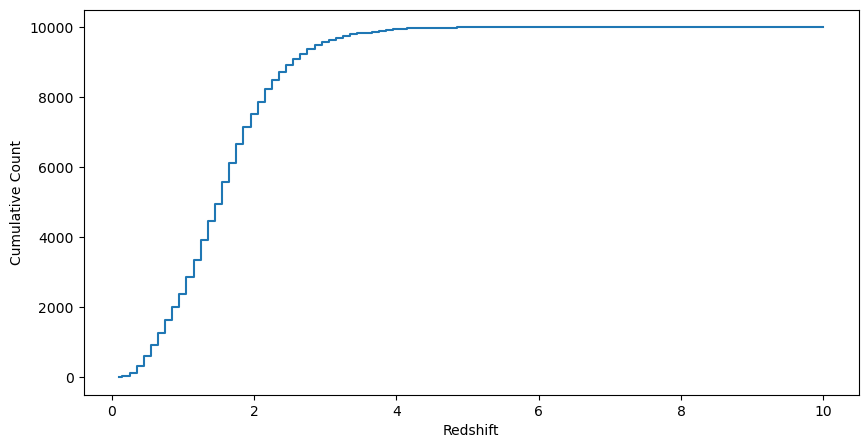

In [101]:
plt.figure(figsize=(10,5))
plt.step(edges[1:],np.cumsum(counts),where='mid')
plt.xlabel('Redshift')
plt.ylabel('Cumulative Count')
plt.show()

In [102]:
nsample = 10000

### Rejection Sampling



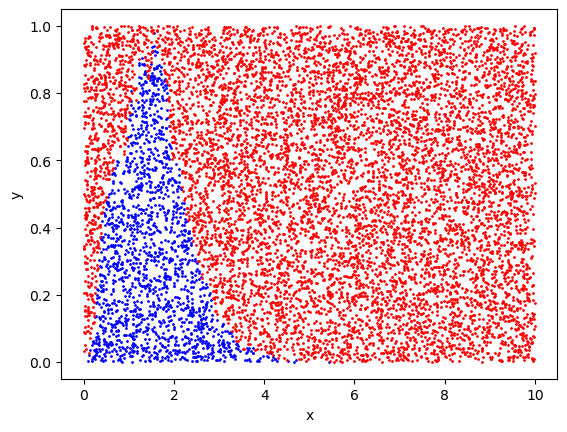

In [103]:
centers = (edges[:-1] + edges[1:])/2
pdf = lambda val: np.interp(val, centers, counts / counts.max(), left=0, right=0)

x_random, y_random = np.random.uniform(0,10,size=nsample), np.random.uniform(0,1,size=nsample)

x_accepted , y_accepted = [], []
x_rejected , y_rejected = [], []

for i in range(nsample):
    if y_random[i] <= pdf(x_random[i]):
        x_accepted.append(x_random[i])
        y_accepted.append(y_random[i])
    else:
        x_rejected.append(x_random[i])
        y_rejected.append(y_random[i])

plt.scatter(x_accepted, y_accepted, color='blue', s=1)
plt.scatter(x_rejected, y_rejected, color='red', s=1)

plt.xlabel('x')
plt.ylabel('y')
plt.show()

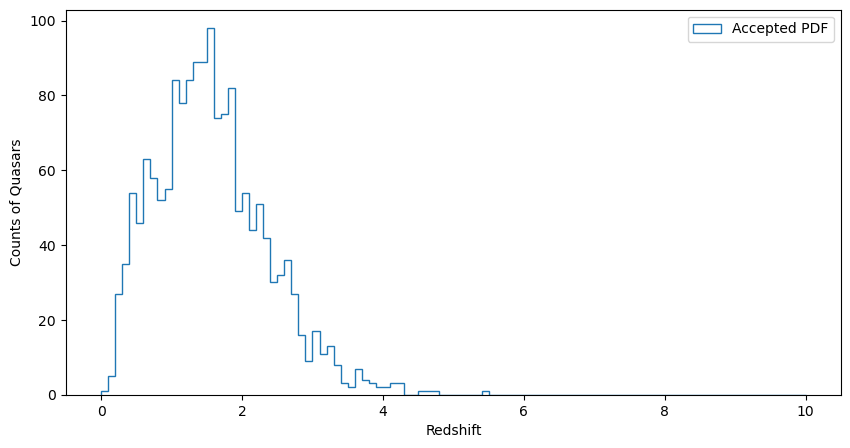

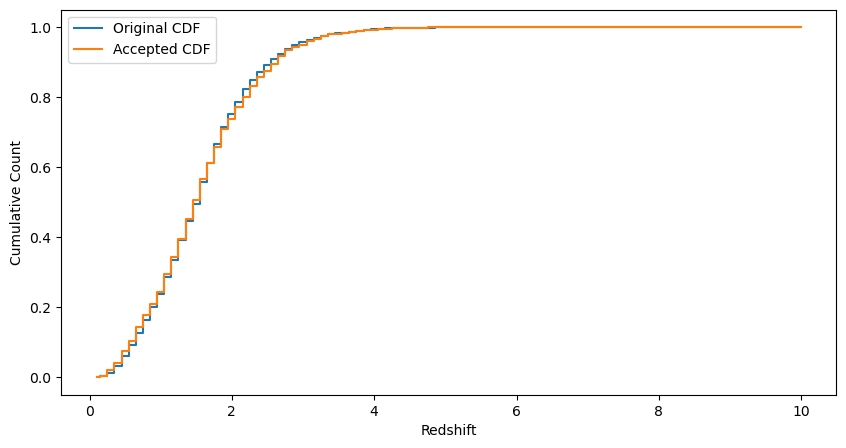

In [108]:
plt.figure(figsize=(10,5))
plt.hist(x_accepted, bins=edges, histtype='step', lw=2, label='Accepted PDF')
plt.xlabel('Redshift')
plt.ylabel("Counts of Quasars")
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.step(edges[1:],np.cumsum(counts)/np.sum(counts),where='mid',label='Original CDF')
plt.step(edges[1:],np.cumsum(np.histogram(x_accepted, bins=edges)[0])/len(x_accepted),where='mid',label='Accepted CDF')
plt.xlabel('Redshift')
plt.ylabel('Cumulative Count')
plt.legend()

### Inverse transform

I'm using monotone-positivity of the cdf to ensure the convergence of the method.

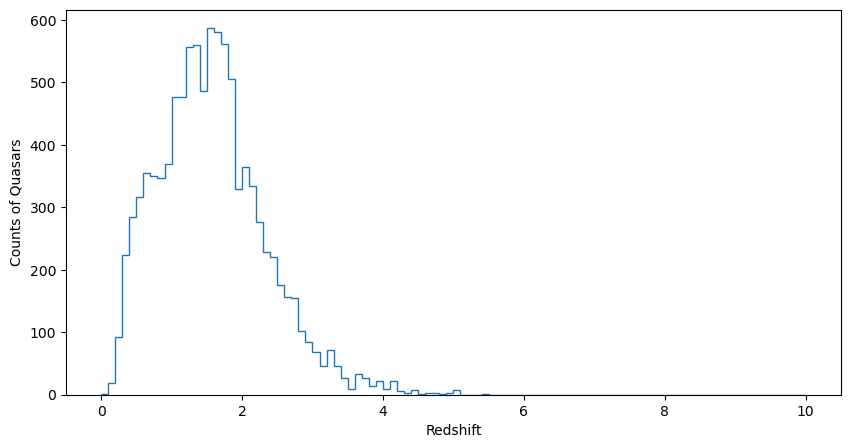

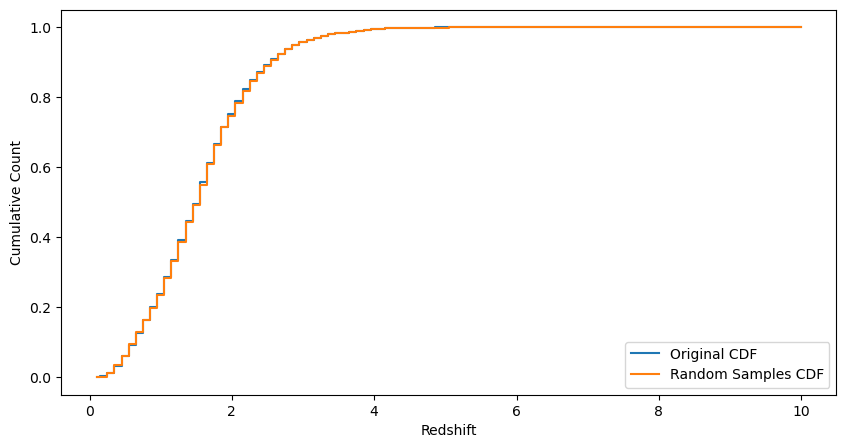

In [109]:
cdf = np.cumsum(counts)/np.sum(counts)

random_samples = np.random.uniform(0,1,size=nsample)

centers = (edges[:-1] + edges[1:])/2

for i in range(len(random_samples)):
    for j in range(len(cdf)):
        if random_samples[i] <= cdf[j]:
            random_samples[i] = centers[j]
            break

plt.figure(figsize=(10,5))
plt.hist(random_samples, bins=np.linspace(0,10,101), histtype='step', lw=2)
plt.xlabel('Redshift')
plt.ylabel("Counts of Quasars")
plt.show()

plt.figure(figsize=(10,5))
plt.step(edges[1:],np.cumsum(counts)/np.sum(counts),where='mid',label='Original CDF')
plt.step(edges[1:],np.cumsum(np.histogram(random_samples, bins=edges)[0])/len(random_samples),where='mid',label='Random Samples CDF')
plt.xlabel('Redshift')
plt.ylabel('Cumulative Count')
plt.legend()
